In [53]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.models import (
    resnet50,   ResNet50_Weights,
    densenet121, DenseNet121_Weights
)

from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print(f'CUDA         : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

PyTorch      : 2.10.0+cu128
Torchvision  : 0.25.0+cu128
CUDA         : True
GPU          : Tesla T4


In [54]:
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [55]:
DATASET_PATHS = [
    '/kaggle/input/plantvillage-dataset/color',
    '/kaggle/input/plant-disease-recognition-dataset/color',
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    '/kaggle/input/plantdisease/color',
]

DATA_DIR = None
for p in DATASET_PATHS:
    if os.path.exists(p):
        DATA_DIR = p
        break

if DATA_DIR is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        if len(dirs) > 5 and all(os.path.isdir(os.path.join(root, d)) for d in dirs[:3]):
            DATA_DIR = root
            break

print(f'Dataset directory: {DATA_DIR}')
assert DATA_DIR is not None, 'Dataset not found — attach PlantVillage dataset to your Kaggle notebook'

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_EPOCHS   = 25
LR           = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.2
TEST_SPLIT   = 0.1
NUM_WORKERS  = 2
DROPOUT      = 0.6

# ── Feature dimensions ────────────────────────────────────────────────────────
# ResNet50   final feature dim : 2048
# DenseNet121 final feature dim: 1024
RESNET_FEAT_DIM   = 2048
DENSENET_FEAT_DIM = 1024
FUSED_DIM         = RESNET_FEAT_DIM + DENSENET_FEAT_DIM   # 3072
HIDDEN_DIM        = 1024

print('Configuration loaded ✓')

Dataset directory: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Configuration loaded ✓


In [56]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),   # ✅ better than resize+crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),            # 🔽 reduced from 25
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 🔽 reduced
    transforms.RandomPerspective(distortion_scale=0.1, p=0.2),  # 🔽 reduced
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Load full dataset ─────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
NUM_CLASSES  = len(full_dataset.classes)
CLASS_NAMES  = full_dataset.classes
total_images = len(full_dataset)

print(f'Total images : {total_images}')
print(f'Num classes  : {NUM_CLASSES}')
print(f'Classes (5)  : {CLASS_NAMES[:5]} ...')

Total images : 17572
Num classes  : 38
Classes (5)  : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] ...


In [57]:
n_test  = int(total_images * TEST_SPLIT)
n_val   = int(total_images * VAL_SPLIT)
n_train = total_images - n_val - n_test

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply train augmentation via wrapper
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        raw_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(raw_path).convert('RGB')
        return self.transform(img), label

train_dataset = TransformSubset(train_dataset, train_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {len(train_dataset):>6} images | {len(train_loader)} batches')
print(f'Val   : {len(val_dataset):>6} images | {len(val_loader)} batches')
print(f'Test  : {len(test_dataset):>6} images | {len(test_loader)} batches')

Train :  12301 images | 769 batches
Val   :   3514 images | 220 batches
Test  :   1757 images | 110 batches


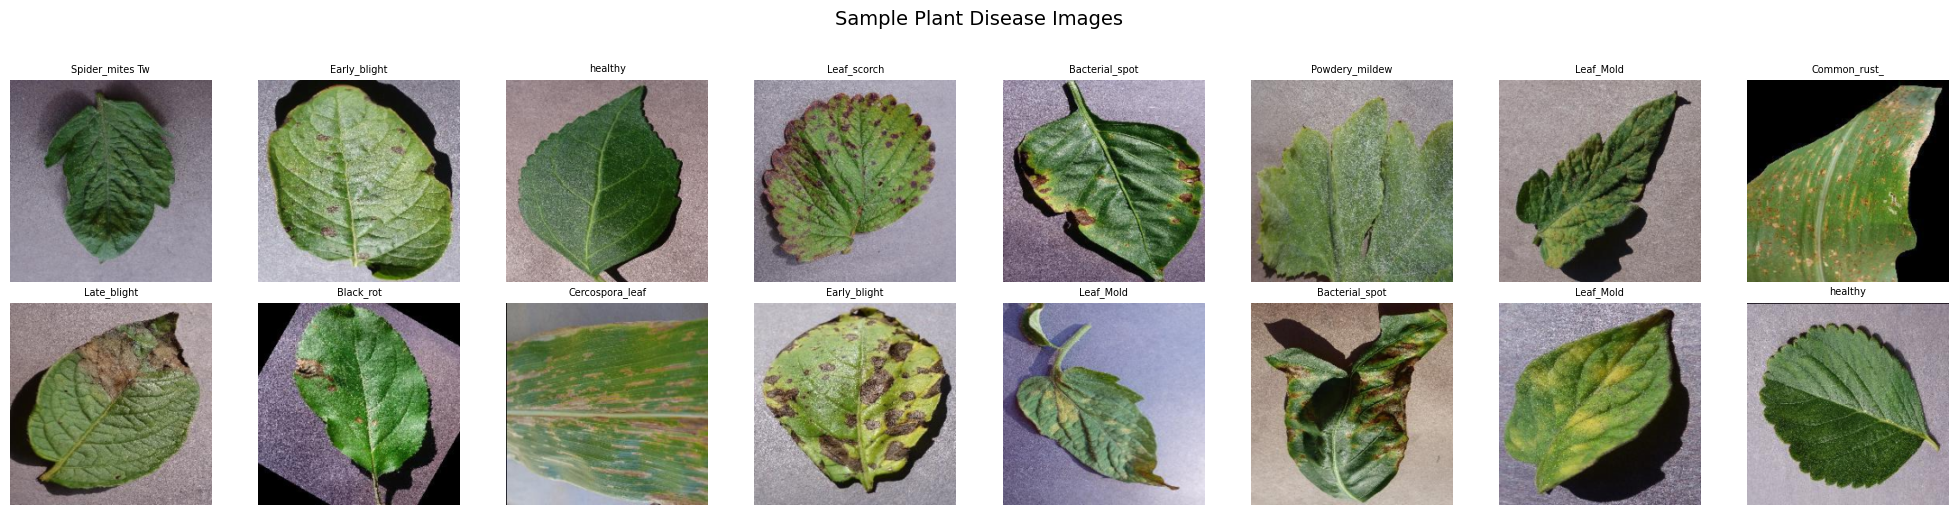

In [58]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

imgs, labels = next(iter(val_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flat):
    if i >= 16: break
    img_show = denormalize(imgs[i]).permute(1,2,0).numpy()
    ax.imshow(img_show)
    ax.set_title(CLASS_NAMES[labels[i].item()].split('___')[-1][:15], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Plant Disease Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [59]:
class SEBlock(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.se = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x)
        return x * scale


# ─────────────────────────────────────────────────────────────────────────────
# Hybrid ResNet50 + DenseNet121 Model
# ─────────────────────────────────────────────────────────────────────────────
class HybridResNetDenseNet(nn.Module):
    """
    Pipeline:
      1. ResNet50   backbone  →  global avg pool  →  (B, 2048)
      2. DenseNet121 backbone →  global avg pool  →  (B, 1024)
      3. Concatenate          →  (B, 3072)
      4. SE Attention         →  recalibrate channels
      5. MLP Classifier       →  (B, num_classes)
    """
    def __init__(
        self,
        num_classes:  int,
        hidden_dim:   int   = 1024,
        dropout:      float = 0.6,
        pretrained:   bool  = True,
    ):
        super().__init__()

        # ── ResNet50 Backbone ────────────────────────────────────────────────
        res_weights  = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        res_model    = resnet50(weights=res_weights)

        # Remove final FC layer — keep up to global avg pool
        self.resnet_backbone = nn.Sequential(*list(res_model.children())[:-1])
        # Output: (B, 2048, 1, 1)  →  flatten  →  (B, 2048)

        # Freeze all except last 2 ResNet layer blocks
        for param in self.resnet_backbone.parameters():
            param.requires_grad = False
        for layer in [self.resnet_backbone[7], self.resnet_backbone[8]]:
            for param in layer.parameters():
                param.requires_grad = True

        # ── DenseNet121 Backbone ─────────────────────────────────────────────
        den_weights   = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        den_model     = densenet121(weights=den_weights)

        # Keep only features block (remove classifier)
        self.densenet_backbone = den_model.features
        self.densenet_pool     = nn.AdaptiveAvgPool2d((1, 1))
        # Output: (B, 1024, 7, 7)  →  pool  →  (B, 1024, 1, 1)  →  flatten  →  (B, 1024)

        # Freeze all except last DenseBlock
        for param in self.densenet_backbone.parameters():
            param.requires_grad = False
        for param in self.densenet_backbone.denseblock4.parameters():
            param.requires_grad = True
        for param in self.densenet_backbone.norm5.parameters():
            param.requires_grad = True

        # ── Fusion & Attention ───────────────────────────────────────────────
        fused_dim = RESNET_FEAT_DIM + DENSENET_FEAT_DIM   # 3072

        self.fusion_norm = nn.BatchNorm1d(fused_dim)
        self.se_block    = SEBlock(fused_dim, reduction=16)

        # ── MLP Classifier ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        # 1. ResNet50 features
        res_feat = self.resnet_backbone(x)          # (B, 2048, 1, 1)
        res_feat = res_feat.flatten(1)              # (B, 2048)

        # 2. DenseNet121 features
        den_feat = self.densenet_backbone(x)        # (B, 1024, 7, 7)
        den_feat = F.relu(den_feat, inplace=True)
        den_feat = self.densenet_pool(den_feat)     # (B, 1024, 1, 1)
        den_feat = den_feat.flatten(1)              # (B, 1024)

        # 3. Concatenate both features
        fused = torch.cat([res_feat, den_feat], dim=1)  # (B, 3072)

        # 4. Normalize + SE attention
        fused = self.fusion_norm(fused)
        fused = self.se_block(fused)

        # 5. Classify
        return self.classifier(fused)               # (B, num_classes)


# ── Instantiate model ─────────────────────────────────────────────────────────
model = HybridResNetDenseNet(
    num_classes=NUM_CLASSES,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    pretrained=True,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print(f'Frozen params    : {total_params - trainable_params:,}')

Total params     : 35,341,798
Trainable params : 22,004,774
Frozen params    : 13,337,024


In [60]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate param groups: lower LR for backbone, higher for classifier
resnet_params   = [p for p in model.resnet_backbone.parameters()   if p.requires_grad]
densenet_params = [p for p in model.densenet_backbone.parameters() if p.requires_grad]
head_params     = (list(model.fusion_norm.parameters()) +
                   list(model.se_block.parameters()) +
                   list(model.classifier.parameters()))

optimizer = optim.AdamW([
    {'params': resnet_params,   'lr': LR * 0.1,  'weight_decay': WEIGHT_DECAY},
    {'params': densenet_params, 'lr': LR * 0.1,  'weight_decay': WEIGHT_DECAY},
    {'params': head_params,     'lr': LR,         'weight_decay': WEIGHT_DECAY},
])

scheduler = OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR * 0.1, LR],
    total_steps=len(train_loader) * NUM_EPOCHS + 10,  # +10 buffer for off-by-one
    pct_start=0.1,
    anneal_strategy='cos',
)

print('Optimizer and scheduler configured ✓')

Optimizer and scheduler configured ✓


In [61]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Mixup
        images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.4)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        # Accuracy: count correct against the dominant label
        correct      += (lam * (preds == labels_a).float() +
                         (1 - lam) * (preds == labels_b).float()).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total * 100

In [62]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total * 100


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total * 100


print('Training functions defined ✓')


Training functions defined ✓


In [63]:
import copy

history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
SAVE_PATH      = '/kaggle/working/best_hybrid_resnet_densenet.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 68)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, DEVICE)

    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    marker  = ' ← best' if val_acc > best_val_acc else ''

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% '
          f'| {val_loss:>8.4f} | {val_acc:>7.2f}%{marker}  [{elapsed:.0f}s]')

    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, SAVE_PATH)

print(f'\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%')
print(f'Model saved to   : {SAVE_PATH}')


 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |   Time
--------------------------------------------------------------------
     1 |     3.0800 |    27.48% |   1.8314 |   76.64% ← best  [156s]
     2 |     1.5428 |    75.29% |   1.0060 |   92.43% ← best  [146s]
     3 |     1.2328 |    83.84% |   0.9255 |   95.08% ← best  [145s]
     4 |     1.1577 |    86.29% |   0.8772 |   96.27% ← best  [144s]
     5 |     1.0983 |    88.35% |   0.8440 |   97.35% ← best  [144s]
     6 |     1.0624 |    89.54% |   0.8309 |   97.30%  [144s]
     7 |     1.0290 |    90.49% |   0.8091 |   97.84% ← best  [144s]
     8 |     1.0109 |    90.97% |   0.8057 |   97.75%  [144s]
     9 |     0.9867 |    91.81% |   0.7939 |   97.92% ← best  [144s]
    10 |     0.9671 |    92.36% |   0.7918 |   98.09% ← best  [144s]
    11 |     0.9563 |    92.64% |   0.7784 |   98.18% ← best  [144s]
    12 |     0.9255 |    93.59% |   0.7701 |   98.35% ← best  [144s]
    13 |     0.9223 |    93.59% |   0.7616 |   98.69% 

Test Accuracy: 98.52%

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00        47
                                 Apple___Black_rot       1.00      1.00      1.00        47
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        49
                                   Apple___healthy       1.00      0.97      0.98        59
                               Blueberry___healthy       0.93      1.00      0.97        42
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00        43
                 Cherry_(including_sour)___healthy       1.00      0.97      0.99        39
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.91      0.93        35
                       Corn_(maize)___Common_rust_       1.00      0.95      0.98        43
               Corn_(maize)___Northern_Leaf_Blight      

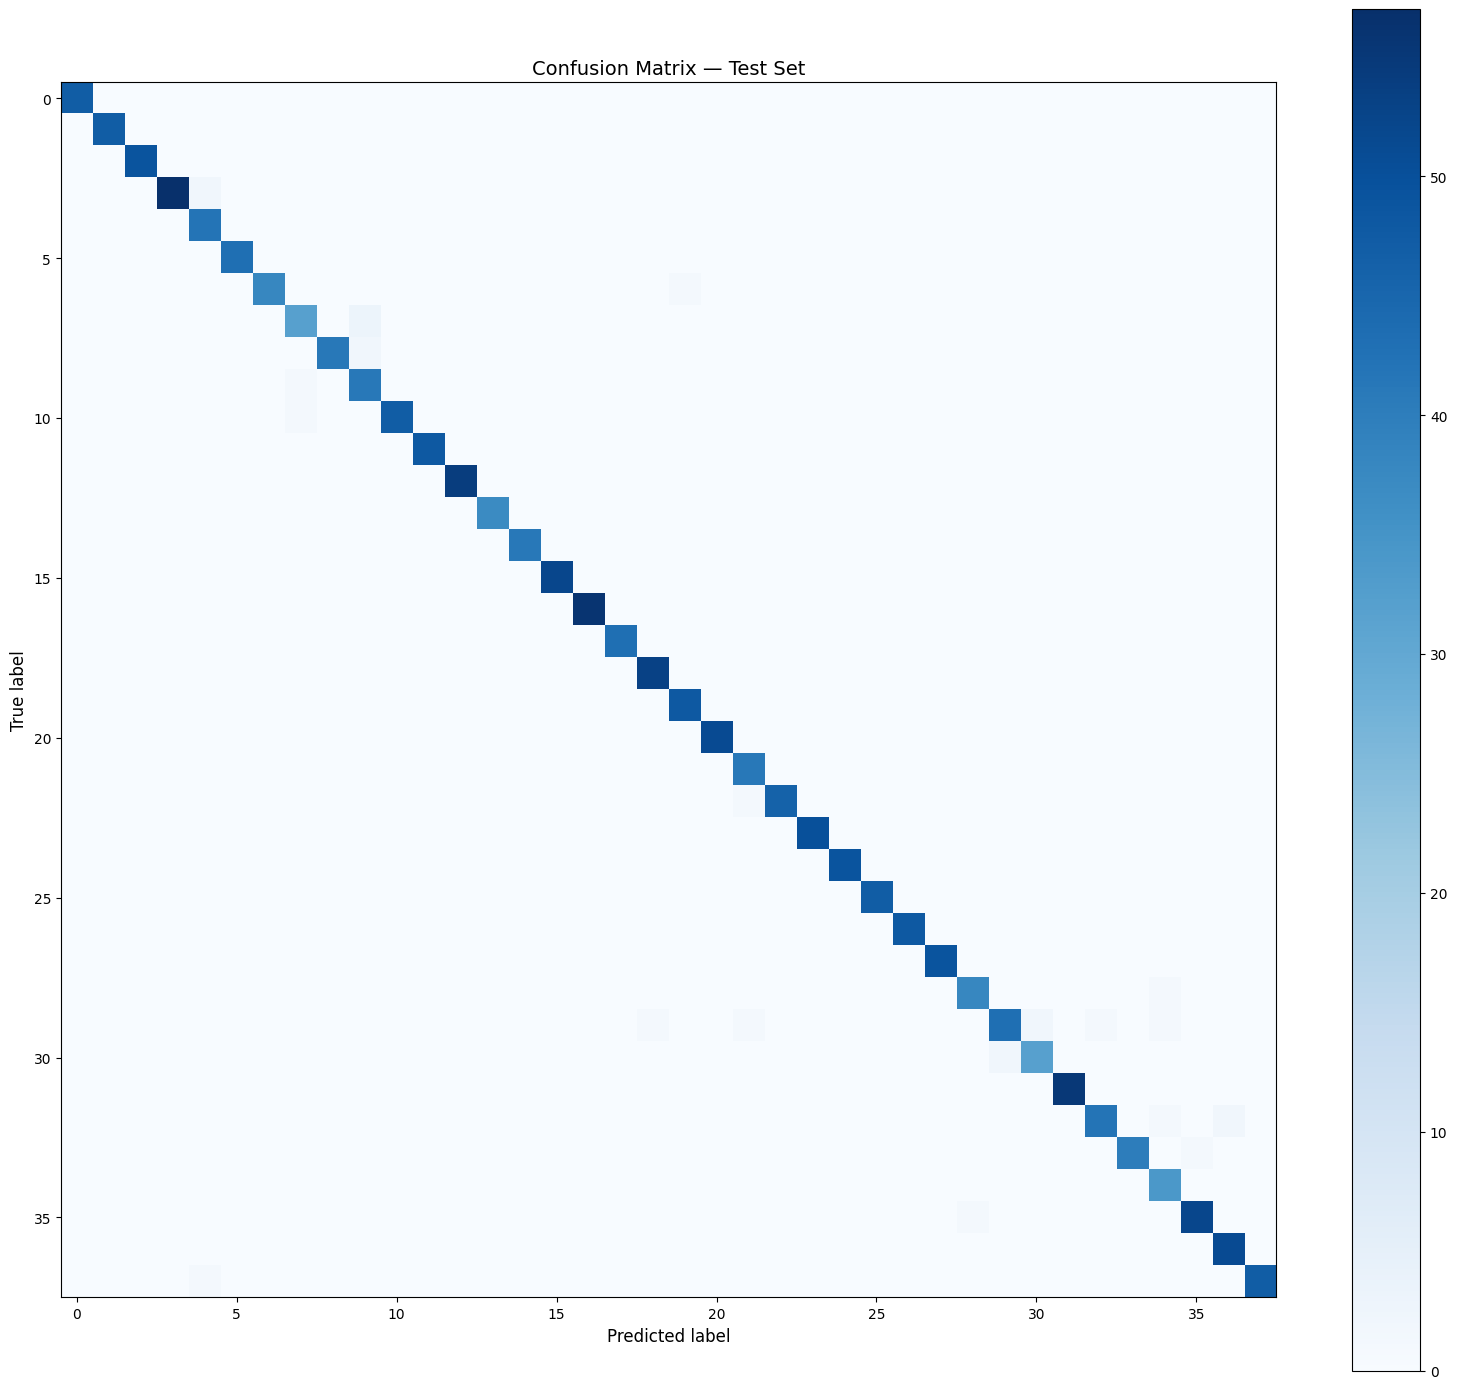

In [64]:
# ── Final Test Evaluation ─────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean() * 100
print(f'Test Accuracy: {test_acc:.2f}%')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

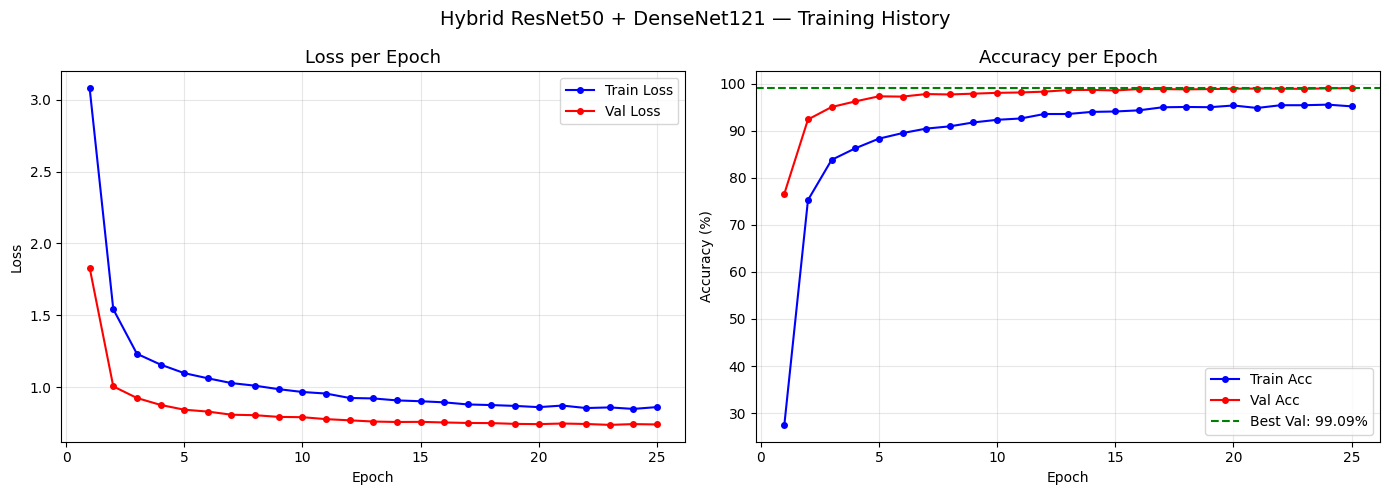

In [65]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--',
                label=f'Best Val: {best_val_acc:.2f}%')
axes[1].set_title('Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Hybrid ResNet50 + DenseNet121 — Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
import copy

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean() * 100
print(f'Test Accuracy : {test_acc:.2f}%')
print(f'Best Val Acc  : {best_val_acc:.2f}%')

Test Accuracy : 98.52%
Best Val Acc  : 99.09%


In [67]:
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        47
                                 Apple___Black_rot     1.0000    1.0000    1.0000        47
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        49
                                   Apple___healthy     1.0000    0.9661    0.9828        59
                               Blueberry___healthy     0.9333    1.0000    0.9655        42
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000        43
                 Cherry_(including_sour)___healthy     1.0000    0.9744    0.9870        39
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9412    0.9143    0.9275        35
                       Corn_(maize)___Common_rust_     1.0000    0.9535    0.9762        43
               Corn_(maize)___Northern_Leaf_Blight     0.8913    0.9762    0.93

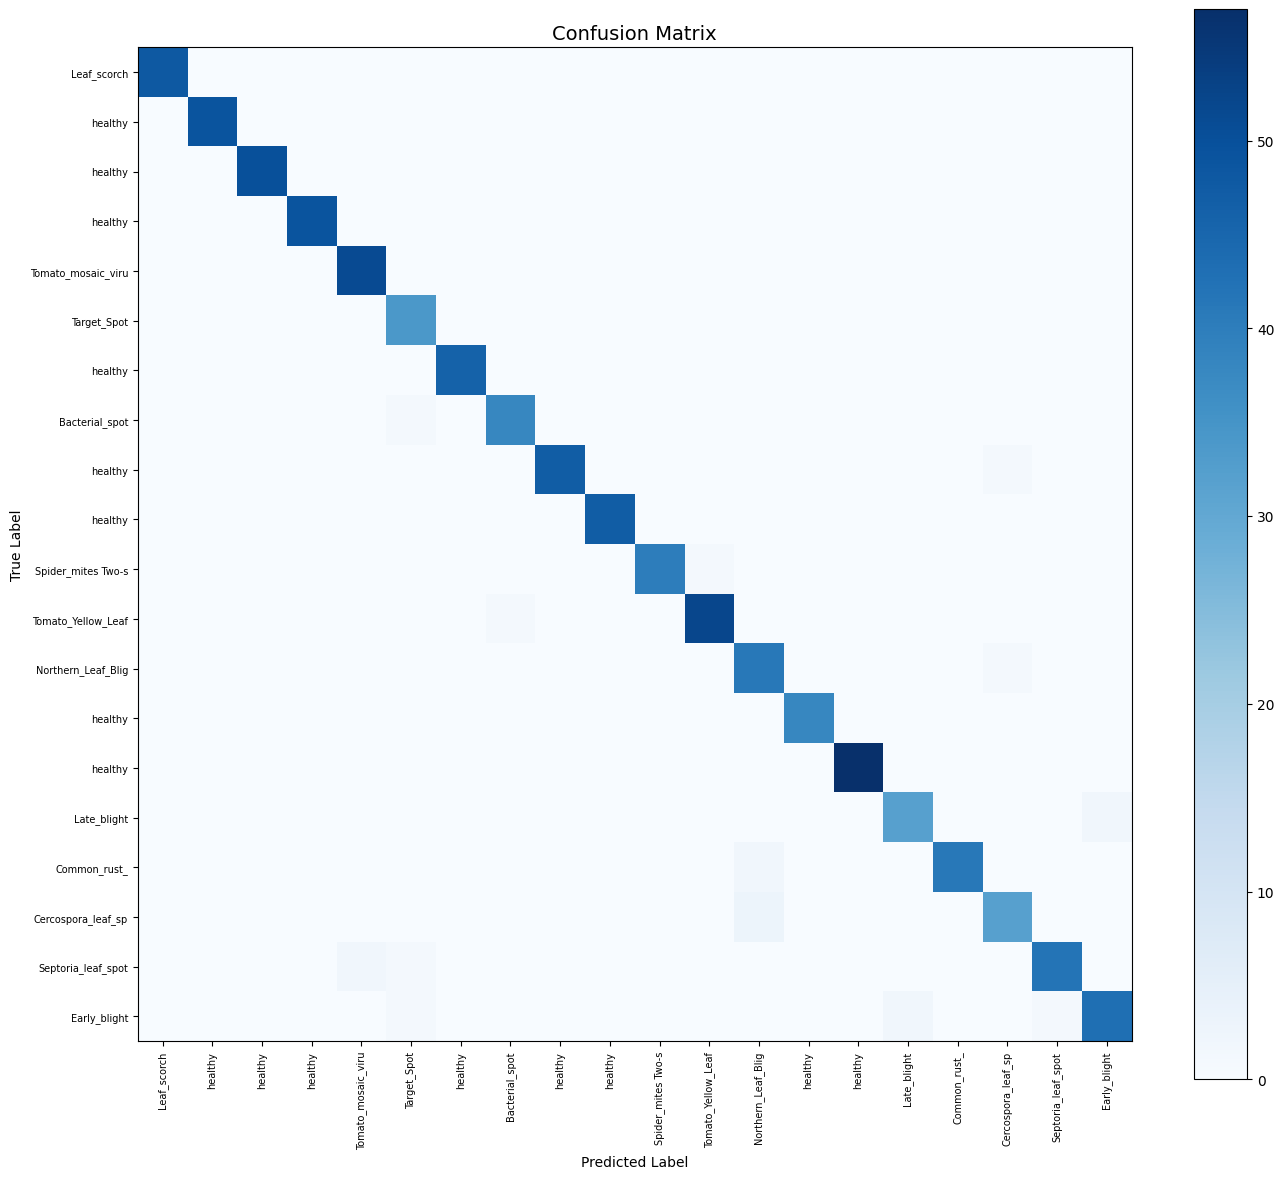

In [68]:
cm = confusion_matrix(all_labels, all_preds)

if NUM_CLASSES <= 20:
    display_classes = [c.split('___')[-1][:18] for c in CLASS_NAMES]
    display_cm      = cm
else:
    per_class_errors = cm.sum(axis=1) - np.diag(cm)
    top20_idx        = np.argsort(per_class_errors)[-20:]
    display_classes  = [CLASS_NAMES[i].split('___')[-1][:18] for i in top20_idx]
    display_cm       = cm[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(display_cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
tick_marks = np.arange(len(display_classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(display_classes, rotation=90, fontsize=7)
ax.set_yticks(tick_marks); ax.set_yticklabels(display_classes, fontsize=7)
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

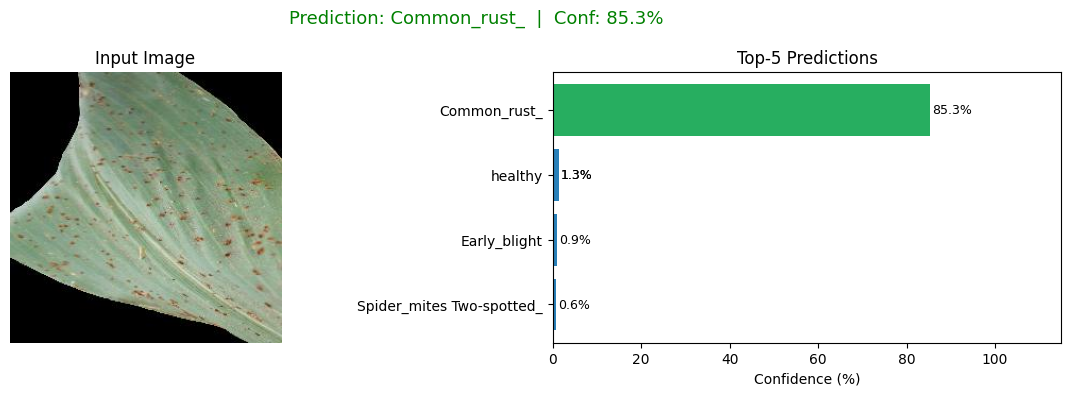


True label : Corn_(maize)___Common_rust_
Predicted  : Corn_(maize)___Common_rust_  (85.3%)

Top-5:
  Corn_(maize)___Common_rust_                         85.26%
  Blueberry___healthy                                  1.31%
  Pepper,_bell___healthy                               1.29%
  Tomato___Early_blight                                0.89%
  Tomato___Spider_mites Two-spotted_spider_mite        0.64%


In [69]:
def predict_single(image_path: str, model, class_names, device, top_k: int = 5):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze(0)

    top_probs, top_idx = probs.topk(top_k)
    top_k_results = [(class_names[i.item()], p.item()*100)
                     for i, p in zip(top_idx, top_probs)]

    pred_class = class_names[top_idx[0].item()]
    confidence = top_probs[0].item() * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title('Input Image', fontsize=12)
    axes[0].axis('off')

    names  = [r[0].split('___')[-1][:25] for r in top_k_results]
    values = [r[1] for r in top_k_results]
    colors = ['#27ae60' if i == 0 else '#2980b9' for i in range(len(names))]

    bars = axes[1].barh(names[::-1], values[::-1], color=colors[::-1])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Top-{top_k} Predictions', fontsize=12)
    for bar, val in zip(bars, values[::-1]):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
    axes[1].set_xlim(0, 115)

    plt.suptitle(f'Prediction: {pred_class.split("___")[-1]}  |  Conf: {confidence:.1f}%',
                 fontsize=13, color='green')
    plt.tight_layout()
    plt.show()

    return pred_class, confidence, top_k_results


# Demo on a random test image
random_idx   = random.randint(0, len(test_dataset) - 1)
sample_path, true_label = full_dataset.samples[test_dataset.indices[random_idx]]

pred_class, confidence, top5 = predict_single(sample_path, model, CLASS_NAMES, DEVICE)

print(f'\nTrue label : {CLASS_NAMES[true_label]}')
print(f'Predicted  : {pred_class}  ({confidence:.1f}%)')
print(f'\nTop-5:')
for name, prob in top5:
    print(f'  {name:<50} {prob:6.2f}%')

In [70]:
print('=' * 65)
print(' HYBRID ResNet50 + DenseNet121 — Architecture Summary')
print('=' * 65)
print(f'  Input               : (B, 3, {IMG_SIZE}, {IMG_SIZE})')
print(f'  ResNet50 backbone   : → Global AvgPool → (B, 2048)')
print(f'  DenseNet121 backbone: → Global AvgPool → (B, 1024)')
print(f'  Concatenation       : (B, 2048) + (B, 1024) = (B, 3072)')
print(f'  BatchNorm1d         : (B, 3072)')
print(f'  SE Attention        : channel recalibration')
print(f'  MLP Head            : 3072 → {HIDDEN_DIM} → {HIDDEN_DIM//2} → {NUM_CLASSES}')
print('=' * 65)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total Parameters    : {total_p:>12,}')
print(f'  Trainable           : {trainable_p:>12,}')
print(f'  Frozen              : {total_p - trainable_p:>12,}')
print('=' * 65)
print(f'\n  Best Validation Acc : {best_val_acc:.2f}%')
print(f'  Test Accuracy       : {test_acc:.2f}%')

 HYBRID ResNet50 + DenseNet121 — Architecture Summary
  Input               : (B, 3, 224, 224)
  ResNet50 backbone   : → Global AvgPool → (B, 2048)
  DenseNet121 backbone: → Global AvgPool → (B, 1024)
  Concatenation       : (B, 2048) + (B, 1024) = (B, 3072)
  BatchNorm1d         : (B, 3072)
  SE Attention        : channel recalibration
  MLP Head            : 3072 → 1024 → 512 → 38
  Total Parameters    :   35,341,798
  Trainable           :   22,004,774
  Frozen              :   13,337,024

  Best Validation Acc : 99.09%
  Test Accuracy       : 98.52%


In [71]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'num_classes':      NUM_CLASSES,
    'hidden_dim':       HIDDEN_DIM,
    'dropout':          DROPOUT,
    'best_val_acc':     best_val_acc,
    'test_acc':         test_acc,
}
torch.save(checkpoint, '/kaggle/working/hybrid_resnet_densenet_checkpoint.pth')
print('Checkpoint saved to /kaggle/working/hybrid_resnet_densenet_checkpoint.pth ✓')

print("""
To reload later:
    ckpt  = torch.load('hybrid_resnet_densenet_checkpoint.pth')
    model = HybridResNetDenseNet(num_classes=len(ckpt['class_names']))
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
""")

Checkpoint saved to /kaggle/working/hybrid_resnet_densenet_checkpoint.pth ✓

To reload later:
    ckpt  = torch.load('hybrid_resnet_densenet_checkpoint.pth')
    model = HybridResNetDenseNet(num_classes=len(ckpt['class_names']))
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()



In [72]:
import hashlib
import os

def get_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# ✅ FIX: access original subset indices
train_paths = [full_dataset.samples[i][0] for i in train_dataset.subset.indices]
val_paths   = [full_dataset.samples[i][0] for i in val_dataset.indices]

# Hashing
train_hashes = set(get_hash(p) for p in train_paths)

leak_count = 0
for p in val_paths:
    if get_hash(p) in train_hashes:
        leak_count += 1

print("🔥 Duplicate images between train & val:", leak_count)


🔥 Duplicate images between train & val: 1


In [73]:
train_names = set(os.path.basename(p) for p in train_paths)
val_names   = set(os.path.basename(p) for p in val_paths)

common = train_names.intersection(val_names)

print("🔥 Same file names:", len(common))


🔥 Same file names: 0


###Testing

In [74]:
model.load_state_dict(torch.load('/kaggle/working/best_hybrid_resnet_densenet.pth'))
model.eval()


HybridResNetDenseNet(
  (resnet_backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
     

In [75]:
import torch

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = 100 * correct / total
print(f"✅ Test Accuracy: {accuracy:.2f}%")


✅ Test Accuracy: 98.52%


In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00        47
                                 Apple___Black_rot       1.00      1.00      1.00        47
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        49
                                   Apple___healthy       1.00      0.97      0.98        59
                               Blueberry___healthy       0.93      1.00      0.97        42
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00        43
                 Cherry_(including_sour)___healthy       1.00      0.97      0.99        39
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.91      0.93        35
                       Corn_(maize)___Common_rust_       1.00      0.95      0.98        43
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.98      0.

In [77]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[47  0  0 ...  0  0  0]
 [ 0 47  0 ...  0  0  0]
 [ 0  0 49 ...  0  0  0]
 ...
 [ 0  0  0 ... 52  0  0]
 [ 0  0  0 ...  0 51  0]
 [ 0  0  0 ...  0  0 47]]


In [78]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(DEVICE)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Pred: {CLASS_NAMES[preds[i]]}\nTrue: {CLASS_NAMES[labels[i]]}")
    plt.axis('off')

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9131652..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.0474076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.367669].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.0299783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..1.6465361].


In [83]:
torch.save(model.state_dict(), "/kaggle/working/best_hybrid_resnet_densenet.pth")


In [82]:

import json
with open("/kaggle/working/classes.json", "w") as f:
    json.dump(CLASS_NAMES, f)